Saved: Figure_5_network  (sigma = 0.1378)


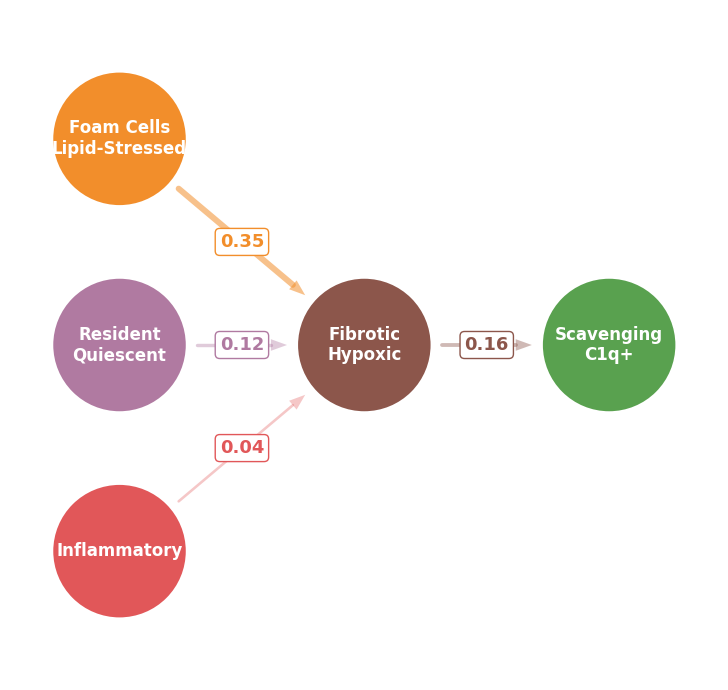

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import numpy as np
from pathlib import Path

BASE        = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
out_dir_net = BASE / "figures/figure5"
out_dir_net.mkdir(parents=True, exist_ok=True)

CLUSTER_COLORS = {
    "Monocytes":                         "#4E79A7",
    "Scavenging / C1q+ Macrophages":     "#59A14F",
    "Resident / Quiescent Macrophages":  "#B07AA1",
    "Inflammatory Macrophages":          "#E15759",
    "Lipid-Stressed / Foam Cells":       "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":    "#8C564B",
}

# ══════════════════════════════════════════════════════════════════
# B=500 CONNECTIVITY — source of truth
# ══════════════════════════════════════════════════════════════════
sigma = 0.1378

CONN = {
    ("Lipid-Stressed / Foam Cells",      "Fibrotic / Hypoxic Macrophages"):  0.349,
    ("Resident / Quiescent Macrophages", "Fibrotic / Hypoxic Macrophages"):  0.119,
    ("Inflammatory Macrophages",         "Fibrotic / Hypoxic Macrophages"):  0.045,
    ("Fibrotic / Hypoxic Macrophages",   "Scavenging / C1q+ Macrophages"):   0.157,
}

def get_conn(src, tgt):
    if (src, tgt) in CONN:
        return CONN[(src, tgt)]
    if (tgt, src) in CONN:
        return CONN[(tgt, src)]
    return None

# ── Equal node radius for every cluster (OT subsamples to 5k) ──
NODE_R = 0.105

# ── Node positions ──
nodes = {
    "Foam Cells\nLipid-Stressed": {
        "pos":   (0.12, 0.82),
        "color": CLUSTER_COLORS["Lipid-Stressed / Foam Cells"],
        "size":  NODE_R,
    },
    "Resident\nQuiescent": {
        "pos":   (0.12, 0.50),
        "color": CLUSTER_COLORS["Resident / Quiescent Macrophages"],
        "size":  NODE_R,
    },
    "Inflammatory": {
        "pos":   (0.12, 0.18),
        "color": CLUSTER_COLORS["Inflammatory Macrophages"],
        "size":  NODE_R,
    },
    "Fibrotic\nHypoxic": {
        "pos":   (0.50, 0.50),
        "color": CLUSTER_COLORS["Fibrotic / Hypoxic Macrophages"],
        "size":  NODE_R,
    },
    "Scavenging\nC1q+": {
        "pos":   (0.88, 0.50),
        "color": CLUSTER_COLORS["Scavenging / C1q+ Macrophages"],
        "size":  NODE_R,
    },
}

# ── Edges (all directed in Axis C) ──
edges = [
    {"src": "Foam Cells\nLipid-Stressed", "tgt": "Fibrotic\nHypoxic", "directed": True,
     "conn": get_conn("Lipid-Stressed / Foam Cells",      "Fibrotic / Hypoxic Macrophages")},
    {"src": "Resident\nQuiescent",        "tgt": "Fibrotic\nHypoxic", "directed": True,
     "conn": get_conn("Resident / Quiescent Macrophages", "Fibrotic / Hypoxic Macrophages")},
    {"src": "Inflammatory",               "tgt": "Fibrotic\nHypoxic", "directed": True,
     "conn": get_conn("Inflammatory Macrophages",         "Fibrotic / Hypoxic Macrophages")},
    {"src": "Fibrotic\nHypoxic",          "tgt": "Scavenging\nC1q+",  "directed": True,
     "conn": get_conn("Fibrotic / Hypoxic Macrophages",   "Scavenging / C1q+ Macrophages")},
]

# ══════════════════════════════════════════════════════════════════
# Illustrator-safe arrow: Line2D shaft + filled Polygon head
# ══════════════════════════════════════════════════════════════════
def draw_arrow(ax, start, end, color, lw, alpha,
               head_len=0.025, head_width=0.018, directed=True):
    start = np.asarray(start, dtype=float)
    end   = np.asarray(end, dtype=float)
    direction = end - start
    L = np.linalg.norm(direction)
    if L < 1e-9:
        return
    unit = direction / L

    if directed:
        shaft_end = end - unit * head_len
        ax.add_line(Line2D([start[0], shaft_end[0]],
                           [start[1], shaft_end[1]],
                           color=color, lw=lw, alpha=alpha,
                           solid_capstyle="round", zorder=2))
        perp = np.array([-unit[1], unit[0]])
        tip   = end
        base  = end - unit * head_len
        left  = base + perp * (head_width / 2)
        right = base - perp * (head_width / 2)
        ax.add_patch(Polygon([tip, left, right], closed=True,
                             facecolor=color, edgecolor=color,
                             linewidth=0, alpha=alpha, zorder=3))
    else:
        ax.add_line(Line2D([start[0], end[0]], [start[1], end[1]],
                           color=color, lw=lw, alpha=alpha,
                           linestyle="--", solid_capstyle="round",
                           zorder=1))

# ── Plot ──
fig_net, ax = plt.subplots(figsize=(8, 7))
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect("equal")
ax.axis("off")

for edge in edges:
    src_pos = np.array(nodes[edge["src"]]["pos"])
    tgt_pos = np.array(nodes[edge["tgt"]]["pos"])
    conn    = edge["conn"]
    if conn is None:
        continue

    direction = tgt_pos - src_pos
    dist      = np.linalg.norm(direction)
    unit      = direction / dist
    src_r     = nodes[edge["src"]]["size"]
    tgt_r     = nodes[edge["tgt"]]["size"]
    start     = src_pos + unit * (src_r + 0.015)
    end       = tgt_pos - unit * (tgt_r + 0.015)

    lw         = 1.5 + conn * 8
    edge_color = nodes[edge["src"]]["color"]
    alpha      = max(0.3, 0.3 + conn * 0.7)

    draw_arrow(ax, start, end, edge_color, lw, alpha,
               directed=edge["directed"])

    mid = (start + end) / 2
    ax.text(mid[0], mid[1], f"{conn:.2f}",
            ha="center", va="center",
            fontsize=13, fontweight="bold",
            color=edge_color,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=edge_color, linewidth=1, alpha=1.0),
            zorder=10)

for name, props in nodes.items():
    circle = plt.Circle(props["pos"], props["size"],
                        color=props["color"], ec="white",
                        linewidth=2, zorder=5)
    ax.add_patch(circle)
    ax.text(props["pos"][0], props["pos"][1], name,
            ha="center", va="center",
            fontsize=12, fontweight="bold",
            color="white", zorder=6)

plt.tight_layout()
for ext in ["pdf", "png"]:
    fig_net.savefig(out_dir_net / f"Figure_5_network.{ext}",
                    bbox_inches="tight", dpi=300, facecolor="white")
print(f"Saved: Figure_5_network  (sigma = {sigma:.4f})")
plt.show()

Saved: /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure5/Figure_5_LOCO_connectivity.pdf


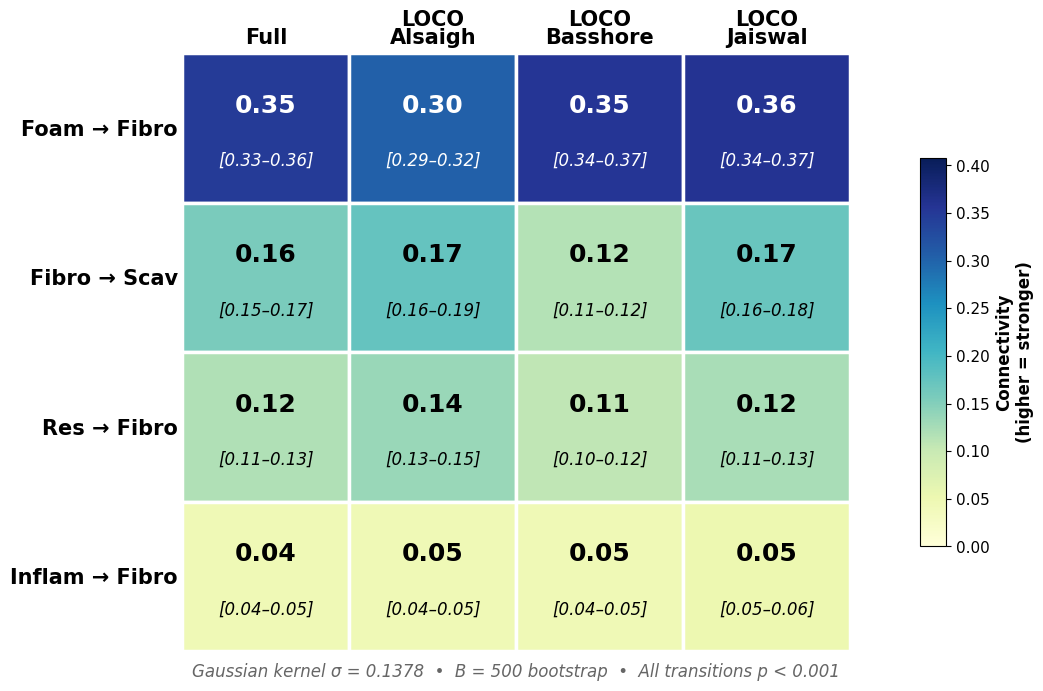

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os

# ── Configuration ──
base = "/storage/homefs/sv24v923/MPI_data/clean_pipeline"
out_dir = os.path.join(base, "figures", "figure5")
os.makedirs(out_dir, exist_ok=True)

# ══════════════════════════════════════════════════════════════════
# FONT SIZE CONTROLS (tweak these to taste)
# ══════════════════════════════════════════════════════════════════
FS_CONN_VALUE   = 18   # Main connectivity number inside each cell
FS_CI_VALUE     = 12   # CI range below the connectivity value
FS_XTICK        = 15   # Run names along the top (Full, LOCO-Alsaigh, ...)
FS_YTICK        = 15   # Transition labels on the left
FS_TITLE        = 16   # Plot title (unused — title removed)
FS_CBAR_LABEL   = 12   # Colorbar label
FS_CBAR_TICKS   = 11   # Colorbar tick labels
FS_FOOTNOTE     = 12   # Sigma / bootstrap footnote

# Vertical placement of CI text relative to the cell center
CI_Y_OFFSET     = 0.22

SHORT = {
    "Scavenging / C1q+ Macrophages":    "Scav",
    "Resident / Quiescent Macrophages": "Res",
    "Inflammatory Macrophages":         "Inflam",
    "Lipid-Stressed / Foam Cells":      "Foam",
    "Fibrotic / Hypoxic Macrophages":   "Fibro",
    "Monocytes":                        "Mono",
}

runs_keys    = ["Full", "LOCO-Alsaigh", "LOCO-Bashore", "LOCO-Jaiswal"]
runs_display = ["Full", "LOCO\nAlsaigh", "LOCO\nBasshore", "LOCO\nJaiswal"]

# ── B=500 directories ────────────────────────────────────────────
run_paths = {
    "Full":         os.path.join(base, "ot_results_v8_full_500_bootstrap"),
    "LOCO-Alsaigh": os.path.join(base, "ot_results_v8_loco_alsaigh_500_bootstrap"),
    "LOCO-Bashore": os.path.join(base, "ot_results_v8_loco_bashore_500_bootstrap"),
    "LOCO-Jaiswal": os.path.join(base, "ot_results_v8_loco_jaiswal_500_bootstrap"),
}

# ── B=500 sigmas ──────────────────────────────────────────────────
SIGMAS = {
    "Full":         0.1378,
    "LOCO-Alsaigh": 0.1463,
    "LOCO-Bashore": 0.1547,
    "LOCO-Jaiswal": 0.1415,
}

# ══════════════════════════════════════════════════════════════════
# B=500 HARDCODED POINT ESTIMATES
# ══════════════════════════════════════════════════════════════════
Foam = "Lipid-Stressed / Foam Cells"
Fibr = "Fibrotic / Hypoxic Macrophages"
Scav = "Scavenging / C1q+ Macrophages"
Res  = "Resident / Quiescent Macrophages"
Infl = "Inflammatory Macrophages"

transitions = [
    (Foam, Fibr),
    (Fibr, Scav),
    (Res,  Fibr),
    (Infl, Fibr),
]

CONN_POINT = {
    (Foam, Fibr): {"Full": 0.349, "LOCO-Alsaigh": 0.304, "LOCO-Bashore": 0.354, "LOCO-Jaiswal": 0.358},
    (Fibr, Scav): {"Full": 0.157, "LOCO-Alsaigh": 0.174, "LOCO-Bashore": 0.115, "LOCO-Jaiswal": 0.172},
    (Res,  Fibr): {"Full": 0.119, "LOCO-Alsaigh": 0.135, "LOCO-Bashore": 0.108, "LOCO-Jaiswal": 0.123},
    (Infl, Fibr): {"Full": 0.045, "LOCO-Alsaigh": 0.046, "LOCO-Bashore": 0.046, "LOCO-Jaiswal": 0.052},
}

# ── Load bootstrap_std for CIs ────────────────────────────────────
def div_to_conn(div_val, sigma):
    return np.exp(-(div_val ** 2) / (2 * sigma ** 2))

def load_ci_from_bootstrap(run_key, src, tgt, conn_point):
    path = run_paths.get(run_key)
    if path is None:
        return conn_point, conn_point

    sigma = SIGMAS[run_key]

    if conn_point <= 0 or conn_point >= 1:
        return conn_point, conn_point
    d = sigma * np.sqrt(-2 * np.log(conn_point))

    std_path = os.path.join(path, "bootstrap_std.csv")
    if not os.path.exists(std_path):
        print(f"  [warn] No bootstrap_std.csv in {path}")
        return conn_point, conn_point

    std_df = pd.read_csv(std_path, index_col=0)
    if src in std_df.index and tgt in std_df.columns:
        std = std_df.loc[src, tgt]
    elif tgt in std_df.index and src in std_df.columns:
        std = std_df.loc[tgt, src]
    else:
        return conn_point, conn_point

    ci_lo = div_to_conn(d + 1.96 * std, sigma)
    ci_hi = div_to_conn(d - 1.96 * std, sigma)
    return ci_lo, ci_hi

# ── Build matrices ────────────────────────────────────────────────
n_trans = len(transitions)
n_runs  = len(runs_keys)

conn_mat       = np.full((n_trans, n_runs), np.nan)
conn_ci_lo_mat = np.full((n_trans, n_runs), np.nan)
conn_ci_hi_mat = np.full((n_trans, n_runs), np.nan)

for i, (src, tgt) in enumerate(transitions):
    for j, run_key in enumerate(runs_keys):
        conn = CONN_POINT[(src, tgt)][run_key]
        conn_mat[i, j] = conn
        ci_lo, ci_hi = load_ci_from_bootstrap(run_key, src, tgt, conn)
        conn_ci_lo_mat[i, j] = ci_lo
        conn_ci_hi_mat[i, j] = ci_hi

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(n_runs * 1.8 + 3.5, n_trans * 1.2 + 2.2))

valid_vals = conn_mat[~np.isnan(conn_mat)]
vmin = max(0, valid_vals.min() - 0.05)
vmax = min(1, valid_vals.max() + 0.05)
cmap = plt.cm.YlGnBu
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for i in range(n_trans):
    for j in range(n_runs):
        conn  = conn_mat[i, j]
        ci_lo = conn_ci_lo_mat[i, j]
        ci_hi = conn_ci_hi_mat[i, j]
        color = cmap(norm(conn)) if not np.isnan(conn) else "#F0F0F0"
        rect  = plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                               facecolor=color, edgecolor="white",
                               linewidth=2.5, zorder=2)
        ax.add_patch(rect)
        if np.isnan(conn):
            continue
        text_color = "white" if norm(conn) > 0.55 else "black"
        ax.text(j, i - 0.15, f"{conn:.2f}", ha="center", va="center",
                fontsize=FS_CONN_VALUE, fontweight="bold",
                color=text_color, zorder=3)

        has_ci = abs(ci_lo - conn) > 0.001 or abs(ci_hi - conn) > 0.001
        if has_ci:
            ax.text(j, i + CI_Y_OFFSET, f"[{ci_lo:.2f}\u2013{ci_hi:.2f}]",
                    ha="center", va="center", fontsize=FS_CI_VALUE,
                    color=text_color, fontstyle="italic", zorder=3)

trans_labels = [f"{SHORT[s]} \u2192 {SHORT[t]}" for s, t in transitions]
ax.set_xticks(range(n_runs))
ax.set_xticklabels(runs_display, fontsize=FS_XTICK,
                   fontweight="bold", linespacing=0.9)
ax.set_yticks(range(n_trans))
ax.set_yticklabels(trans_labels, fontsize=FS_YTICK, fontweight="bold")
ax.set_xlim(-0.5, n_runs - 0.5)
ax.set_ylim(-0.5, n_trans - 0.5)
ax.invert_yaxis()
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.65, aspect=15, pad=0.08)
cbar.set_label("Connectivity\n(higher = stronger)",
               fontsize=FS_CBAR_LABEL, fontweight="bold")
cbar.ax.tick_params(labelsize=FS_CBAR_TICKS)

sigma_full = SIGMAS["Full"]
ax.text(0.5, -0.02,
        f"Gaussian kernel \u03c3 = {sigma_full:.4f}  \u2022  "
        f"B = 500 bootstrap  \u2022  All transitions p < 0.001",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=FS_FOOTNOTE, fontstyle="italic", color="#666666")

plt.tight_layout()
save_path = os.path.join(out_dir, "Figure_5_LOCO_connectivity.pdf")
plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")
save_path_png = os.path.join(out_dir, "Figure_5_LOCO_connectivity.png")
plt.savefig(save_path_png, bbox_inches="tight", dpi=300, facecolor="white")
print(f"Saved: {save_path}")
plt.show()

/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/_utils/__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/storage/homefs/sv24v923/.conda/envs/py311_r_env/lib/python3.11/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):



Loading Inflam → Fibro...
  Shape after cleaning: (20391, 2000)
  ✅ Saved fig5B_Inflam_to_Fibro.pdf
  ✅ Saved fig5B_Inflam_to_Fibro.png


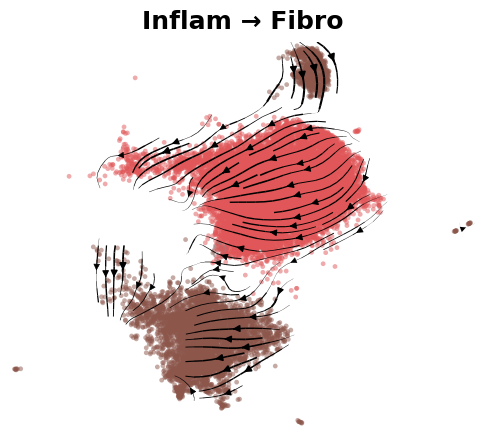


Loading Scav → Fibro...
  Shape after cleaning: (26630, 2000)
  ✅ Saved fig5B_Scav_to_Fibro.pdf
  ✅ Saved fig5B_Scav_to_Fibro.png


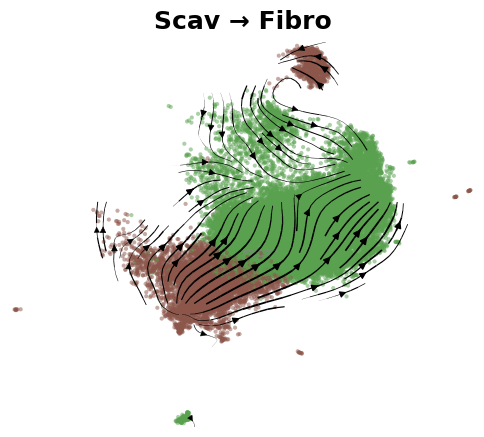


Loading Foam → Fibro...
  Shape after cleaning: (14446, 2000)
  ✅ Saved fig5B_Foam_to_Fibro.pdf
  ✅ Saved fig5B_Foam_to_Fibro.png


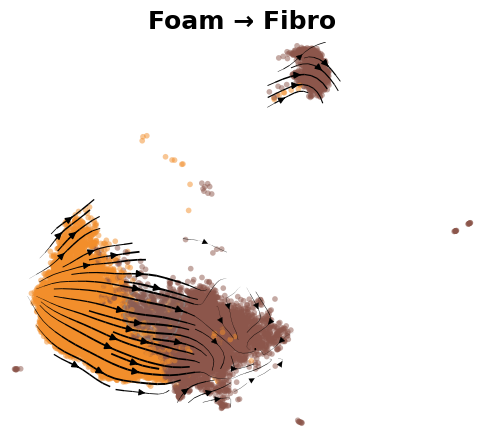


Loading Res → Fibro...
  Shape after cleaning: (16169, 2000)
  ✅ Saved fig5B_Res_to_Fibro.pdf
  ✅ Saved fig5B_Res_to_Fibro.png


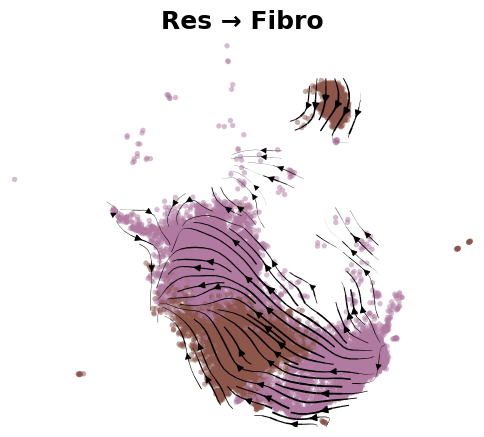


Creating combined 2x2 figure...

Loading Inflam → Fibro for combined figure...

Loading Scav → Fibro for combined figure...

Loading Foam → Fibro for combined figure...

Loading Res → Fibro for combined figure...
  ✅ Saved fig5B_combined_2x2.pdf
  ✅ Saved fig5B_combined_2x2.png


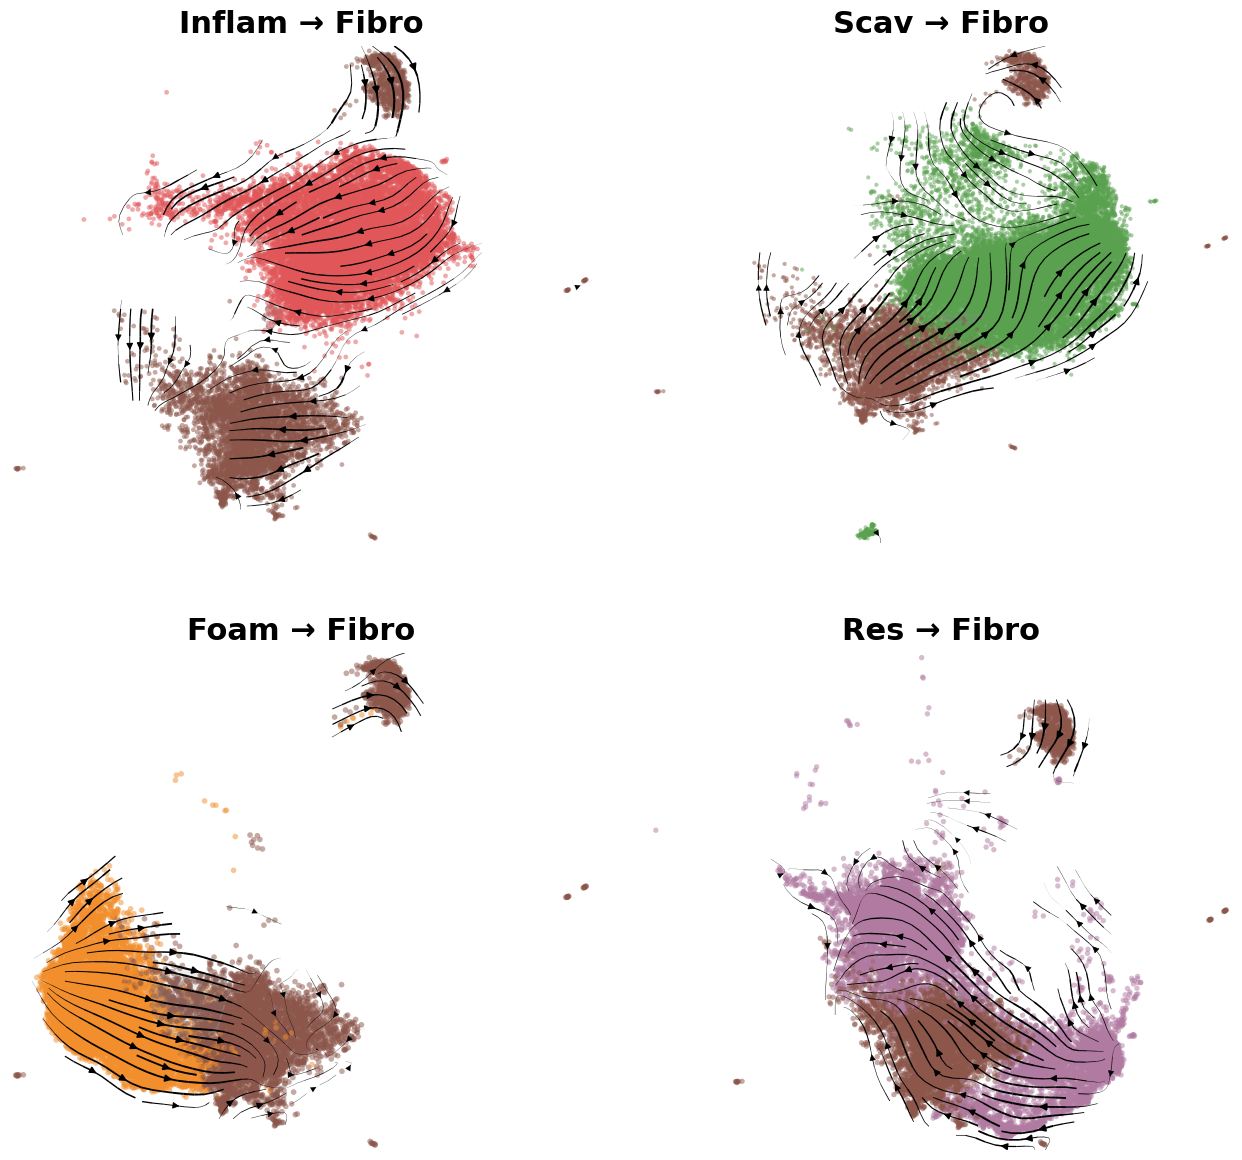


✅ Fig5B done — saved to /storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure_panels_B


In [3]:
# %% Fig5B — UniTVelo velocity streams: Routes to fibrosis
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from pathlib import Path
from scipy.spatial import ConvexHull
from sklearn.neighbors import NearestNeighbors
import gc

scv.settings.verbosity = 1

VELO_DIR = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/unitvelo_results_META_VALIDATION_V2")
OUT_DIR  = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline/figures/figure_panels_B")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    "Monocytes":                        "#4E79A7",
    "Scavenging / C1q+ Macrophages":    "#59A14F",
    "Resident / Quiescent Macrophages": "#B07AA1",
    "Inflammatory Macrophages":         "#E15759",
    "Lipid-Stressed / Foam Cells":      "#F28E2B",
    "Fibrotic / Hypoxic Macrophages":   "#8C564B",
}

SHORT_NAMES = {
    "Monocytes":                        "Monocytes",
    "Scavenging / C1q+ Macrophages":    "Scav / C1q+",
    "Resident / Quiescent Macrophages": "Resident",
    "Inflammatory Macrophages":         "Inflammatory",
    "Lipid-Stressed / Foam Cells":      "Foam Cells",
    "Fibrotic / Hypoxic Macrophages":   "Fibrotic",
}

CT_COL = "cell_type_meta_v2"

FIG5_TRANSITIONS = [
    ("Inflammatory_Macrophages_to_Fibrotic___Hypoxic_Macrophages",         "Inflam → Fibro"),
    ("Scavenging___C1qp_Macrophages_to_Fibrotic___Hypoxic_Macrophages",    "Scav → Fibro"),
    ("Lipid-Stressed___Foam_Cells_to_Fibrotic___Hypoxic_Macrophages",      "Foam → Fibro"),
    ("Resident___Quiescent_Macrophages_to_Fibrotic___Hypoxic_Macrophages", "Res → Fibro"),
]


def clean_adata(adata):
    finite_mask = np.ones(adata.n_obs, dtype=bool)
    for key in ["X_umap", "velocity_umap", "X_scanorama", "X_diffmap"]:
        if key in adata.obsm:
            arr = adata.obsm[key]
            if hasattr(arr, "toarray"):
                arr = arr.toarray()
            bad = ~np.isfinite(arr).all(axis=1)
            if bad.any():
                print(f"  {key}: {bad.sum()} non-finite cells")
                finite_mask &= ~bad
    n_removed = (~finite_mask).sum()
    if n_removed > 0:
        print(f"  Removing {n_removed} non-finite cells ({n_removed/adata.n_obs*100:.1f}%)")
        adata = adata[finite_mask].copy()
    if "velocity_umap" in adata.obsm:
        adata.obsm["velocity_umap"] = np.nan_to_num(
            adata.obsm["velocity_umap"], nan=0.0, posinf=0.0, neginf=0.0)
    return adata


def rasterize_data_artists(ax):
    from matplotlib.collections import PathCollection, LineCollection
    from matplotlib.lines import Line2D
    from matplotlib.patches import FancyArrowPatch
    for artist in ax.get_children():
        if isinstance(artist, (PathCollection, LineCollection, FancyArrowPatch)):
            artist.set_rasterized(True)
        elif isinstance(artist, Line2D):
            if artist.get_xdata().size > 2:
                artist.set_rasterized(True)


def safe_save(fig, path_stem, dpi=300):
    for ax in fig.axes:
        rasterize_data_artists(ax)
    pdf_path = f"{path_stem}.pdf"
    try:
        fig.savefig(pdf_path, bbox_inches="tight", dpi=dpi,
                    format="pdf", backend="pdf")
        print(f"  ✅ Saved {Path(path_stem).name}.pdf")
    except Exception as e:
        print(f"  ⚠ PDF failed: {e}")
    fig.savefig(f"{path_stem}.png", bbox_inches="tight", dpi=300)
    print(f"  ✅ Saved {Path(path_stem).name}.png")


def draw_transition_interface(ax, adata, ct_col, k_neighbors=20,
                               color="#888888", alpha_fill=0.15, expand=0.05,
                               radius_frac=0.25):
    umap  = adata.obsm["X_umap"]
    types = adata.obs[ct_col].values
    cats  = list(adata.obs[ct_col].cat.categories)

    if len(cats) != 2:
        return

    ct_a, ct_b = cats[0], cats[1]

    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm="ball_tree", n_jobs=1)
    nbrs.fit(umap)
    _, indices = nbrs.kneighbors(umap)

    boundary_a = np.zeros(adata.n_obs, dtype=bool)
    boundary_b = np.zeros(adata.n_obs, dtype=bool)

    for idx in np.where(types == ct_a)[0]:
        if ct_b in types[indices[idx, 1:]]:
            boundary_a[idx] = True
    for idx in np.where(types == ct_b)[0]:
        if ct_a in types[indices[idx, 1:]]:
            boundary_b[idx] = True

    boundary_pts = umap[boundary_a | boundary_b]
    if len(boundary_pts) < 4:
        return

    centroid_a   = umap[types == ct_a].mean(axis=0)
    centroid_b   = umap[types == ct_b].mean(axis=0)
    midpoint     = (centroid_a + centroid_b) / 2
    span         = np.linalg.norm(centroid_a - centroid_b)
    radius       = span * radius_frac

    dists_to_mid = np.linalg.norm(boundary_pts - midpoint, axis=1)
    core_pts     = boundary_pts[dists_to_mid < radius]

    if len(core_pts) < 4:
        core_pts = boundary_pts

    centroid = core_pts.mean(axis=0)
    dirs     = core_pts - centroid
    norms    = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms    = np.where(norms == 0, 1, norms)
    expanded = core_pts + expand * (dirs / norms)

    try:
        hull = ConvexHull(expanded)
    except Exception as e:
        print(f"  ⚠ ConvexHull failed: {e}")
        return

    hull_pts = expanded[hull.vertices]
    hull_pts = np.vstack([hull_pts, hull_pts[0]])

    ax.fill(hull_pts[:, 0], hull_pts[:, 1],
            color=color, alpha=alpha_fill, zorder=1.5, linewidth=0)
    ax.plot(hull_pts[:, 0], hull_pts[:, 1],
            color=color, alpha=0.6, linewidth=1.2,
            linestyle="--", zorder=1.6)


def plot_velocity_panel(adata, ax, title, show_interface=True,
                        show_legend=False, title_fontsize=22):
    cats = adata.obs[CT_COL].cat.categories.tolist()
    adata.uns[f"{CT_COL}_colors"] = [COLORS.get(c, "#CCCCCC") for c in cats]

    scv.pl.velocity_embedding_stream(
        adata, basis="umap", color=CT_COL,
        title="", legend_loc="none", ax=ax, show=False,
        density=1.8, linewidth=0.8, arrow_size=1.0,
        alpha=0.5, min_mass=2.0,
    )

    if show_interface:
        draw_transition_interface(ax, adata, CT_COL)

    if ax.get_legend():
        ax.get_legend().remove()

    if show_legend:
        present_cats = [c for c in cats if c in adata.obs[CT_COL].values]
        handles = [
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=COLORS.get(c, "#CCCCCC"),
                       markersize=10, label=SHORT_NAMES.get(c, c),
                       markeredgecolor="white", markeredgewidth=0.5)
            for c in present_cats
        ]
        ax.legend(
            handles=handles,
            fontsize=10, loc="lower left", frameon=True,
            facecolor="white", edgecolor="#AAAAAA",
            framealpha=0.95, markerscale=1.3,
            ncol=1, borderpad=0.8, labelspacing=0.6,
        )

    ax.set_title(title, fontsize=title_fontsize, fontweight="bold", pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")


# ── Individual panels ─────────────────────────────────────────────
for fname_stem, title in FIG5_TRANSITIONS:
    fpath = VELO_DIR / f"unitvelo_pairwise_{fname_stem}.h5ad"
    if not fpath.exists():
        print(f"⚠ Missing: {fpath.name}")
        continue

    print(f"\nLoading {title}...")
    adata = sc.read_h5ad(fpath)
    adata = clean_adata(adata)
    print(f"  Shape after cleaning: {adata.shape}")

    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_facecolor("white")
    plot_velocity_panel(adata, ax, title, show_legend=False, title_fontsize=18)

    safe_name = title.replace(" → ", "_to_").replace(" ", "")
    safe_save(fig, OUT_DIR / f"fig5B_{safe_name}")
    plt.show()

    del adata
    gc.collect()


# ── Combined 2x2 figure (no legend, no suptitle) ──────────────────
print("\nCreating combined 2x2 figure...")

fig = plt.figure(figsize=(13, 12))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.22, wspace=0.10,
                       top=0.96, bottom=0.04, left=0.04, right=0.98)

panel_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
]

for ax, (fname_stem, title) in zip(panel_axes, FIG5_TRANSITIONS):
    fpath = VELO_DIR / f"unitvelo_pairwise_{fname_stem}.h5ad"
    if not fpath.exists():
        print(f"⚠ Missing: {fpath.name}")
        ax.axis("off")
        continue

    print(f"\nLoading {title} for combined figure...")
    adata = sc.read_h5ad(fpath)
    adata = clean_adata(adata)
    plot_velocity_panel(adata, ax, title,
                        show_legend=False, title_fontsize=22)
    del adata
    gc.collect()

safe_save(fig, OUT_DIR / "fig5B_combined_2x2")
plt.show()
print(f"\n✅ Fig5B done — saved to {OUT_DIR}")

Running 1000 permutations per panel...

  Inflam → Fibro — 14,907 cells, 1000 permutations...


  Done in 3.3s
  Gene           Obs FC   Perm p   Sig
  ----------------------------------------
  SPP1           +0.952   0.0010   ***
  LGALS1         +0.846   0.0010   ***
  S100A10        +0.701   0.0010   ***
  CAPG           +0.737   0.0010   ***
  CXCL8          -0.254   0.0010   ***
  TNF            -0.373   0.0010   ***
  IL1B           -0.161   0.0010   ***

  Foam → Fibro — 8,962 cells, 1000 permutations...
  Done in 2.2s
  Gene           Obs FC   Perm p   Sig
  ----------------------------------------
  CAPG           +0.511   0.0010   ***
  LGALS3         +0.449   0.0010   ***
  LGALS1         +0.236   0.0010   ***
  ANXA2          +0.187   0.0010   ***
  FABP5          +0.193   0.0010   ***
  CSTB           +0.269   0.0010   ***
  PLIN2          -0.064   0.0010   ***

  Res → Fibro — 10,685 cells, 1000 permutations...
  Done in 2.6s
  Gene           Obs FC   Perm p   Sig
  ----------------------------------------
  SPP1           +1.989   0.0010   ***
  CAPG           +1.

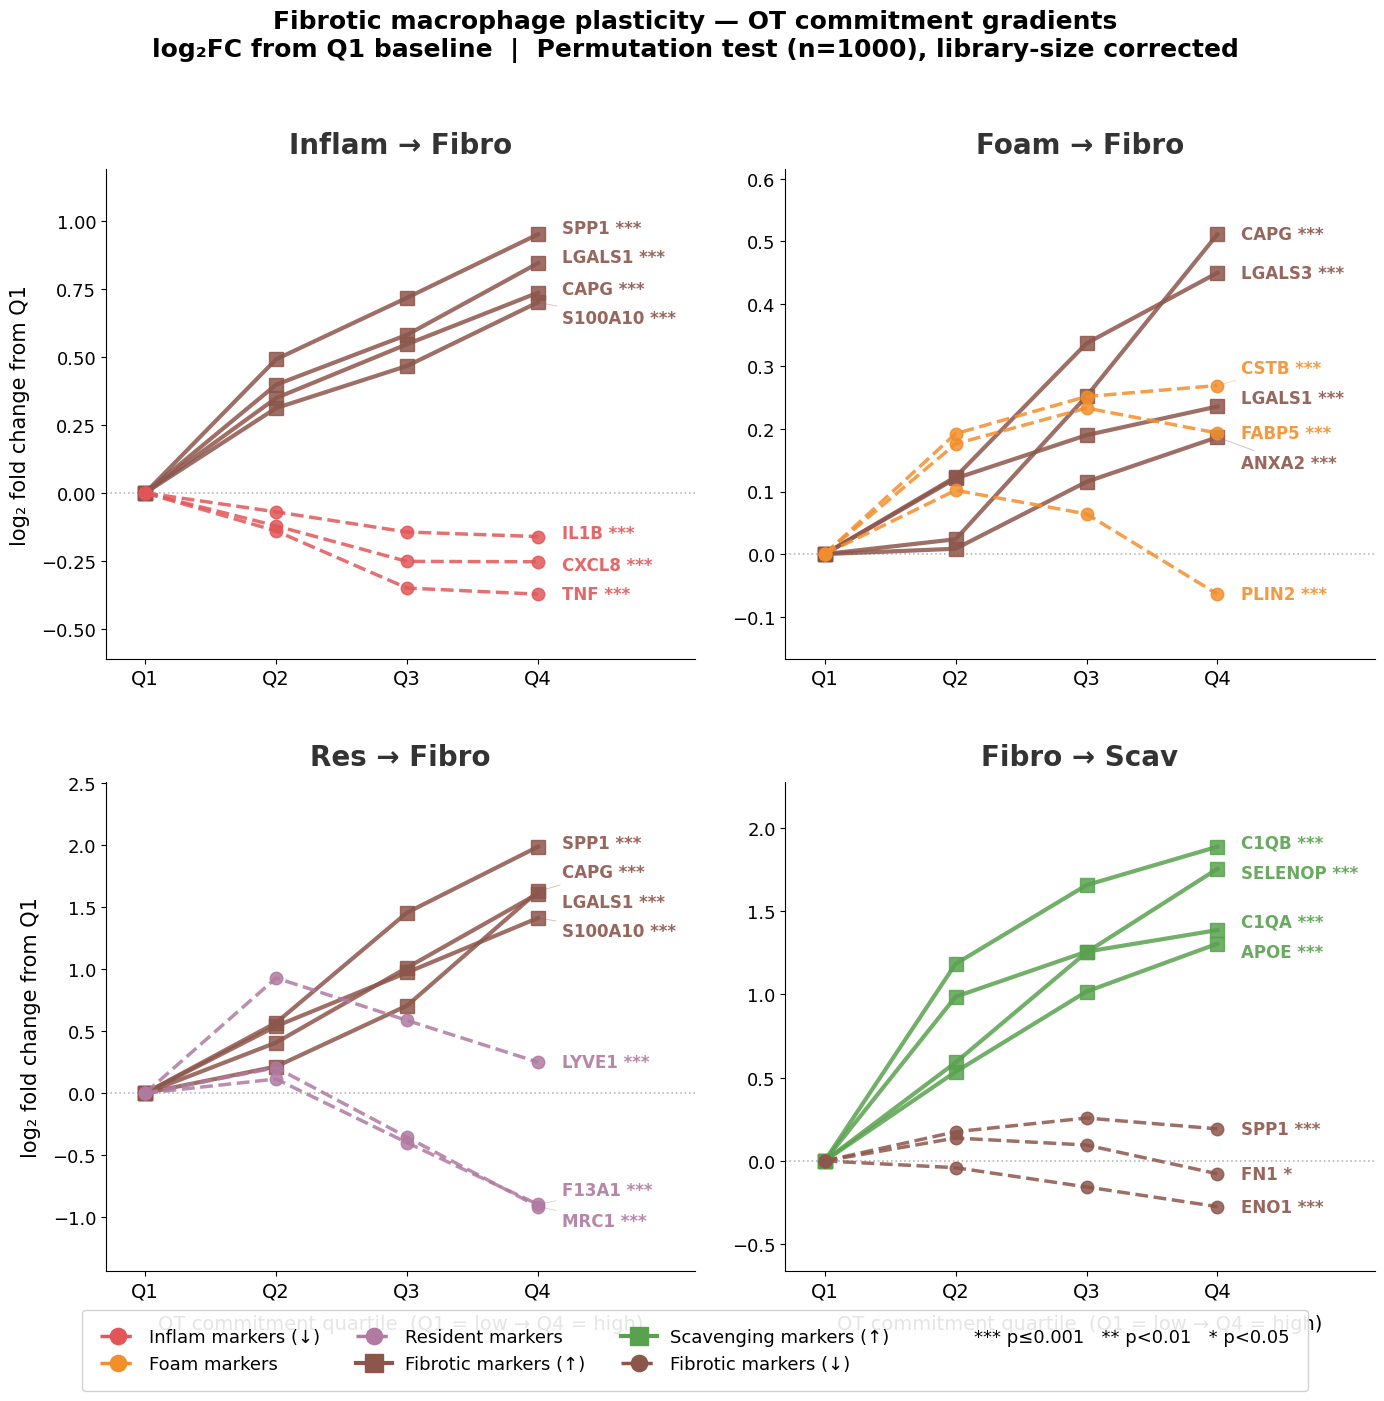

✅ Fig5D saved


In [4]:
# %% FIG 5D — Fibrotic macrophage plasticity + permutation test
# 2x2 layout: top-left=Inflam→Fibro, top-right=Foam→Fibro,
#             bottom-left=Res→Fibro, bottom-right=Fibro→Scav
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import time

BASE          = Path("/storage/homefs/sv24v923/MPI_data/clean_pipeline")
CORRECTED_DIR = BASE / "ot_gradients_corrected"
OUT_DIR       = BASE / "figures/figure_panels_D_v5"
OUT_DIR.mkdir(parents=True, exist_ok=True)

Q_ORDER = ["Q1", "Q2", "Q3", "Q4"]
PSEUDO  = 0.1
N_PERM  = 1000

COLORS = {
    "Mono":   "#4E79A7",
    "Scav":   "#59A14F",
    "Res":    "#B07AA1",
    "Inflam": "#E15759",
    "Foam":   "#F28E2B",
    "Fibro":  "#8C564B",
}

# ══════════════════════════════════════════════════════════════════
# STYLE — adjust any of these freely
# ══════════════════════════════════════════════════════════════════
STYLE = {
    # Figure
    "figsize":              (14, 13),
    "h_pad":                4.0,
    "w_pad":                2.5,

    # Marker sizes (per series)
    "ms_target":            10,    # target gene markers (squares)
    "ms_source":            9,     # source gene markers (circles)

    # Line widths
    "lw_target":            3.0,
    "lw_source":            2.5,
    "lw_zero":              1.2,

    # Subplot title (Inflam → Fibro, etc.)
    "title_fontsize":       20,
    "title_pad":            12,

    # Axis tick + label sizes
    "xtick_fontsize":       14,
    "ytick_fontsize":       13,
    "ylabel_fontsize":      15,
    "ylabel_pad":           8,
    "xlabel_fontsize":      14,
    "xlabel_pad":           10,

    # Endpoint gene labels
    "endpoint_fontsize":    12,
    "endpoint_offset_x":    0.18,

    # Horizontal legend below panels
    "legend_fontsize":      13,
    "legend_marker_scale":  1.3,
    "legend_y":             -0.04,

    # Suptitle
    "suptitle_fontsize":    18,
    "suptitle_y":           1.03,
}

FIG5D_PANELS = [
    {"csv": "Inflam_to_Fibro.csv", "title": "Inflam → Fibro",
     "src_type": "Inflam", "tgt_type": "Fibro",
     "src_genes": ["CXCL8", "TNF", "IL1B"],
     "tgt_genes": ["SPP1", "LGALS1", "S100A10", "CAPG"]},
    {"csv": "Foam_to_Fibro.csv", "title": "Foam → Fibro",
     "src_type": "Foam", "tgt_type": "Fibro",
     "src_genes": ["FABP5", "CSTB", "PLIN2"],
     "tgt_genes": ["CAPG", "LGALS3", "LGALS1", "ANXA2"]},
    {"csv": "Res_to_Fibro.csv", "title": "Res → Fibro",
     "src_type": "Res", "tgt_type": "Fibro",
     "src_genes": ["LYVE1", "F13A1", "MRC1"],
     "tgt_genes": ["SPP1", "CAPG", "LGALS1", "S100A10"]},
    {"csv": "Fibro_to_Scav.csv", "title": "Fibro → Scav",
     "src_type": "Fibro", "tgt_type": "Scav",
     "src_genes": ["FN1", "SPP1", "ENO1"],
     "tgt_genes": ["C1QA", "C1QB", "APOE", "SELENOP"]},
]


def perm_stars(p):
    if p <= 0.001: return "***"
    if p < 0.01:   return "**"
    if p < 0.05:   return "*"
    return "ns"


def observed_log2fc(expr, quartile_labels):
    q1 = expr[quartile_labels == "Q1"].mean()
    q4 = expr[quartile_labels == "Q4"].mean()
    return np.log2((q4 + PSEUDO) / (q1 + PSEUDO))


def run_permutation_test(df, genes, n_perm=N_PERM, seed=42):
    rng      = np.random.default_rng(seed)
    weights  = df["ot_weight_corrected"].values.copy()
    avail    = [g for g in genes if g in df.columns]
    expr_mat = df[avail].values.astype(np.float32)
    obs_q    = df["ot_quartile_corrected"].values.astype(str)
    obs_fc   = {gene: observed_log2fc(expr_mat[:, gi], obs_q)
                for gi, gene in enumerate(avail)}
    null_fcs = {gene: [] for gene in avail}
    for _ in range(n_perm):
        shuffled = rng.permutation(weights)
        null_q   = pd.qcut(shuffled, q=4, labels=Q_ORDER).astype(str)
        for gi, gene in enumerate(avail):
            null_fcs[gene].append(observed_log2fc(expr_mat[:, gi], null_q))
    perm_pvals = {}
    for gene in avail:
        null = np.array(null_fcs[gene])
        p    = (np.abs(null) >= np.abs(obs_fc[gene])).mean()
        perm_pvals[gene] = max(p, 1.0 / n_perm)
    return perm_pvals, obs_fc


def load_panel(panel):
    t0        = time.time()
    df        = pd.read_csv(CORRECTED_DIR / panel["csv"])
    all_genes = list(dict.fromkeys(panel["tgt_genes"] + panel["src_genes"]))
    missing   = [g for g in all_genes if g not in df.columns]
    if missing:
        print(f"  ⚠ {panel['csv']} missing: {missing}")
    available = [g for g in all_genes if g in df.columns]
    print(f"\n  {panel['title']} — {len(df):,} cells, {N_PERM} permutations...")
    qm = df.groupby("ot_quartile_corrected",
                    observed=True)[available].mean().loc[Q_ORDER]
    qm_fc = pd.DataFrame(index=Q_ORDER, columns=available, dtype=float)
    for gene in available:
        q1_val = qm.loc["Q1", gene]
        for q in Q_ORDER:
            qm_fc.loc[q, gene] = np.log2(
                (qm.loc[q, gene] + PSEUDO) / (q1_val + PSEUDO))
    perm_pvals, obs_fc = run_permutation_test(df, available)
    print(f"  Done in {time.time()-t0:.1f}s")
    print(f"  {'Gene':<12} {'Obs FC':>8} {'Perm p':>8} {'Sig':>5}")
    print(f"  {'-'*40}")
    for gene in available:
        print(f"  {gene:<12} {obs_fc[gene]:>+8.3f} "
              f"{perm_pvals[gene]:>8.4f} {perm_stars(perm_pvals[gene]):>5}")
    return {"cfg": panel, "qm_fc": qm_fc, "perm_pvals": perm_pvals}


def spread_labels(endpoints, min_gap):
    if not endpoints:
        return []
    eps       = sorted(enumerate(endpoints), key=lambda t: t[1][0])
    positions = [ep[0] for _, ep in eps]
    indices   = [idx for idx, _ in eps]
    for _ in range(200):
        moved = False
        for i in range(len(positions) - 1):
            gap = positions[i + 1] - positions[i]
            if gap < min_gap:
                shift             = (min_gap - gap) / 2 + 0.005
                positions[i]     -= shift
                positions[i + 1] += shift
                moved = True
        if not moved:
            break
    result = [None] * len(endpoints)
    for si, oi in enumerate(indices):
        result[oi] = positions[si]
    return result


def plot_log2fc(ax, pd_item):
    cfg, qm_fc, pvals = pd_item["cfg"], pd_item["qm_fc"], pd_item["perm_pvals"]
    x       = np.arange(4)
    tgt_col = COLORS[cfg["tgt_type"]]
    src_col = COLORS[cfg["src_type"]]

    all_fc = []
    for g in cfg["tgt_genes"] + cfg["src_genes"]:
        if g in qm_fc.columns:
            all_fc.extend([float(qm_fc.loc[q, g]) for q in Q_ORDER])
    fc_min, fc_max = (min(all_fc), max(all_fc)) if all_fc else (-1, 1)
    fc_range = max(fc_max - fc_min, 0.5)
    min_gap  = fc_range * 0.08

    def plot_genes(genes, color, marker, ms, lw, ls):
        endpoints = []
        for gene in genes:
            if gene not in qm_fc.columns:
                continue
            vals = [float(qm_fc.loc[q, gene]) for q in Q_ORDER]
            ax.plot(x, vals, marker=marker, markersize=ms, linewidth=lw,
                    color=color, alpha=0.85, linestyle=ls, zorder=3)
            sig   = perm_stars(pvals.get(gene, 1.0))
            label = f"{gene} {sig}" if sig != "ns" else gene
            endpoints.append((vals[3], label, color))
        return endpoints

    tgt_ep = plot_genes(cfg["tgt_genes"], tgt_col, "s",
                        STYLE["ms_target"], STYLE["lw_target"], "-")
    src_ep = plot_genes(cfg["src_genes"], src_col, "o",
                        STYLE["ms_source"], STYLE["lw_source"], "--")

    xlim_right = 4.2
    ax.plot([-0.3, xlim_right], [0, 0],
            color="#999999", linewidth=STYLE["lw_zero"],
            linestyle=":", zorder=1, alpha=0.7)

    all_endpoints = tgt_ep + src_ep
    y_pad = fc_range * 0.18
    ax.set_ylim(fc_min - y_pad, fc_max + y_pad)

    if all_endpoints:
        raw      = [(y, lbl) for (y, lbl, _) in all_endpoints]
        adjusted = spread_labels(raw, min_gap)
        for (raw_y, label, color), label_y in zip(all_endpoints, adjusted):
            use_arrow = abs(raw_y - label_y) > min_gap * 0.4
            ax.annotate(
                label, xy=(3, raw_y),
                xytext=(3 + STYLE["endpoint_offset_x"], label_y),
                fontsize=STYLE["endpoint_fontsize"], fontweight="bold",
                color=color, va="center", ha="left", alpha=0.9,
                arrowprops=dict(arrowstyle="-", color=color,
                                lw=0.6, alpha=0.4) if use_arrow else None)

    ax.set_xticks(x)
    ax.set_xticklabels(Q_ORDER, fontsize=STYLE["xtick_fontsize"])
    ax.set_xlim(-0.3, xlim_right)
    ax.set_title(cfg["title"], fontsize=STYLE["title_fontsize"],
                 fontweight="bold", color="#333", pad=STYLE["title_pad"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=STYLE["ytick_fontsize"])


# ── Load ──────────────────────────────────────────────────────────
t_total = time.time()
print(f"Running {N_PERM} permutations per panel...")
fig5_data = [load_panel(p) for p in FIG5D_PANELS]
print(f"\nAll panels done in {(time.time()-t_total)/60:.1f} min")

# ── 2x2 layout ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=STYLE["figsize"])
fig.patch.set_facecolor("white")

axes_flat = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

for ax, pd_item in zip(axes_flat, fig5_data):
    plot_log2fc(ax, pd_item)

# y-axis labels on left column
axes[0, 0].set_ylabel("log₂ fold change from Q1",
                      fontsize=STYLE["ylabel_fontsize"],
                      labelpad=STYLE["ylabel_pad"])
axes[1, 0].set_ylabel("log₂ fold change from Q1",
                      fontsize=STYLE["ylabel_fontsize"],
                      labelpad=STYLE["ylabel_pad"])

# x-axis labels on bottom row
axes[1, 0].set_xlabel("OT commitment quartile  (Q1 = low → Q4 = high)",
                      fontsize=STYLE["xlabel_fontsize"],
                      labelpad=STYLE["xlabel_pad"])
axes[1, 1].set_xlabel("OT commitment quartile  (Q1 = low → Q4 = high)",
                      fontsize=STYLE["xlabel_fontsize"],
                      labelpad=STYLE["xlabel_pad"])

# ── Horizontal legend below panels ────────────────────────────────
legend_entries = [
    Line2D([0], [0], color=COLORS["Inflam"], lw=STYLE["lw_source"], ls="--",
           marker="o", ms=STYLE["ms_source"], label="Inflam markers (↓)"),
    Line2D([0], [0], color=COLORS["Foam"],   lw=STYLE["lw_source"], ls="--",
           marker="o", ms=STYLE["ms_source"], label="Foam markers"),
    Line2D([0], [0], color=COLORS["Res"],    lw=STYLE["lw_source"], ls="--",
           marker="o", ms=STYLE["ms_source"], label="Resident markers"),
    Line2D([0], [0], color=COLORS["Fibro"],  lw=STYLE["lw_target"], ls="-",
           marker="s", ms=STYLE["ms_target"], label="Fibrotic markers (↑)"),
    Line2D([0], [0], color=COLORS["Scav"],   lw=STYLE["lw_target"], ls="-",
           marker="s", ms=STYLE["ms_target"], label="Scavenging markers (↑)"),
    Line2D([0], [0], color=COLORS["Fibro"],  lw=STYLE["lw_source"], ls="--",
           marker="o", ms=STYLE["ms_source"], label="Fibrotic markers (↓)"),
    Line2D([0], [0], color="none", marker="None", ls="None",
           label="*** p≤0.001   ** p<0.01   * p<0.05"),
]
fig.legend(handles=legend_entries,
           loc="lower center", ncol=4,
           fontsize=STYLE["legend_fontsize"],
           frameon=True, framealpha=0.9, edgecolor="#cccccc",
           bbox_to_anchor=(0.5, STYLE["legend_y"]),
           markerscale=STYLE["legend_marker_scale"],
           borderpad=1.0, columnspacing=2.0, handletextpad=0.7)

fig.suptitle(
    "Fibrotic macrophage plasticity — OT commitment gradients\n"
    f"log₂FC from Q1 baseline  |  Permutation test (n={N_PERM}), "
    "library-size corrected",
    fontsize=STYLE["suptitle_fontsize"], fontweight="bold",
    y=STYLE["suptitle_y"])

plt.tight_layout(h_pad=STYLE["h_pad"], w_pad=STYLE["w_pad"])
for ext in ["pdf", "png"]:
    fig.savefig(OUT_DIR / f"fig5D_log2fc_FINAL.{ext}",
                bbox_inches="tight", dpi=300)
plt.show()
print("✅ Fig5D saved")